# Refining the recipe to write SSH from the LLC

In [1]:
from importlib import reload

import os

import xarray
import json
import dask
import numpy as np
from xmitgcm import llcreader

from remote_sensing.plotting import globe
from remote_sensing.healpix import utils as hputils

#from xarray.core.combine import _nested_combine
from functools import partial
from fronts.llc.slurp import write_xr
from fronts.llc import io as llc_io

# Load up the SSH data

In [2]:
ssh = np.load('tst_data.npy')
ssh

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

## Load up the coords

In [5]:
coords = llc_io.load_coords()

Loading LLC coords from /home/xavier/Projects/Oceanography/data/OGCM/LLC/LLC_coords.nc


In [4]:
coords

<xarray.Dataset> Size: 4GB
Dimensions:  (x: 12960, y: 17280)
Coordinates:
    lon      (x, y) float32 896MB -114.9 -114.9 -114.9 ... -38.01 -38.0 -38.0
    lat      (x, y) float32 896MB -88.18 -88.18 -88.18 -88.19 ... 67.5 67.5 67.5
Dimensions without coordinates: x, y
Data variables:
    zero     (x, y) int64 2GB 0 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0

# Plot me

(<GeoAxes: >, <matplotlib.collections.PathCollection at 0x726e9dd4dbe0>)

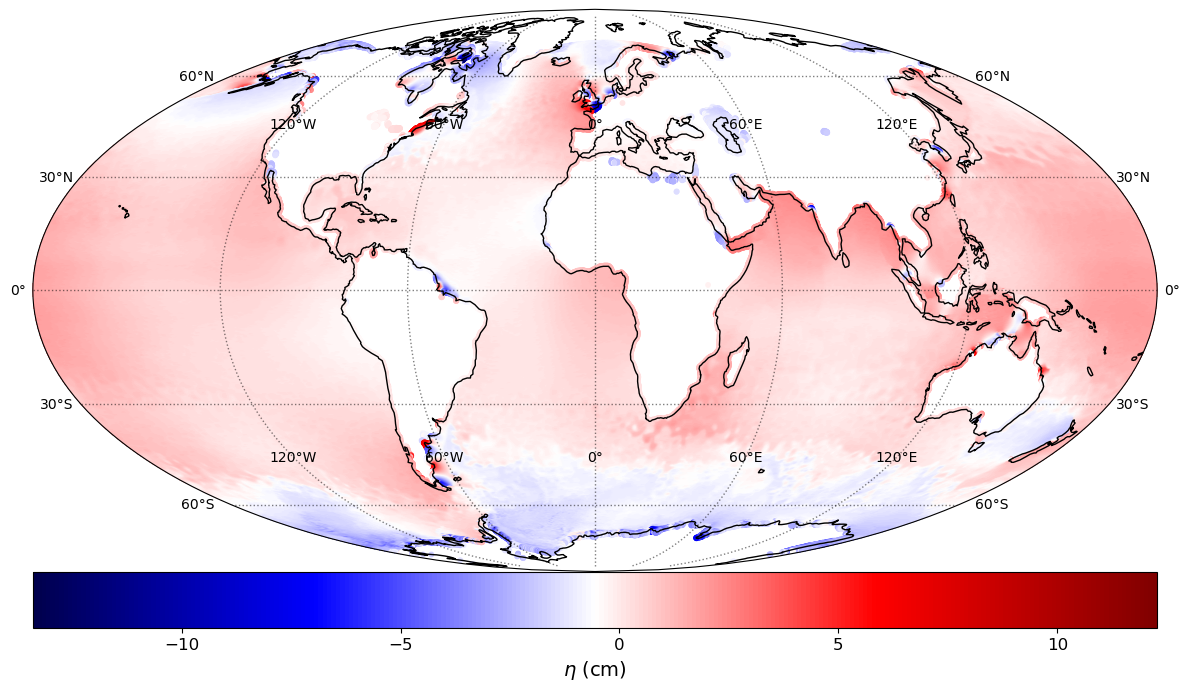

In [8]:
reload(globe)
reload(hputils)
globe.healpix_map(coords.lat.data, coords.lon.data, ssh, cmap='seismic', cb_lbl=r'$\eta$ (cm)',
                 nside=512)

## Plot just a smaller region (Gulf Stream)

In [12]:
coords.lon.min()

<xarray.DataArray 'lon' ()> Size: 4B
array(-179.99998, dtype=float32)

In [33]:
lat_lim = (35.,40.)
lon_lim = (-60., -50.)
near_gs = (coords.lat > lat_lim[0]) & (coords.lat < lat_lim[1]) & (coords.lon > lon_lim[0]) & (coords.lon < lon_lim[1])

gs_lon = coords.lon.data[near_gs]
gs_lat = coords.lat.data[near_gs]
gs_ssh = ssh[near_gs]

In [34]:
absmax = np.max(np.abs(gs_ssh))

In [21]:
lat_lim

(35.0, 40.0)

In [25]:
lat_lim, lon_lim

((35.0, 40.0), (-60.0, -50.0))

(<GeoAxes: >, <matplotlib.collections.PathCollection at 0x726e7aaaf350>)

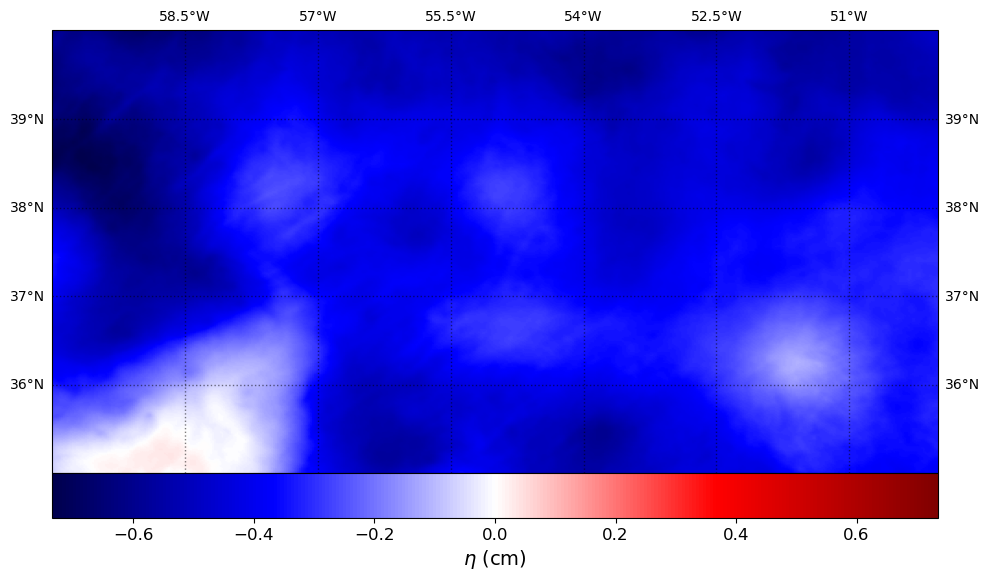

In [35]:
reload(globe)
globe.plot_lons_lats_vals(gs_lon, gs_lat, gs_ssh, cmap='seismic', cb_lbl=r'$\eta$ (cm)',
                         lat_lim=lat_lim, lon_lim=lon_lim, projection='platecarree',
                         figsize=(10,10), vmin=-absmax, vmax=absmax) #(300., 310))

# Write with encoding

In [39]:
# Assuming your data is in an xarray DataArray or Dataset
ni, nj = ssh.shape
ds = xarray.Dataset(
    {
        'ssh': (['i', 'j'], ssh)
    },
    coords={
        'i': np.arange(ni),
        'j': np.arange(nj)
    }
)

# Define encoding with compression and int16 conversion
encoding = {
    'ssh': {
        'dtype': 'int16',
        'scale_factor': 0.001,  # Adjust based on desired precision
        'add_offset': 0.0,
        'zlib': True,           # Enable compression
        'complevel': 4,         # Compression level (1-9, 4 is good balance)
        '_FillValue': -32767    # Missing value indicator for int16
    }
}

# Write to disk
ds.to_netcdf('ssh_data.nc', encoding=encoding)

# Read back in

In [42]:
ds2 = xarray.open_dataset('ssh_data.nc')

In [43]:
ds2

<xarray.Dataset> Size: 2GB
Dimensions:  (i: 12960, j: 17280)
Coordinates:
  * i        (i) int64 104kB 0 1 2 3 4 5 ... 12954 12955 12956 12957 12958 12959
  * j        (j) int64 138kB 0 1 2 3 4 5 ... 17274 17275 17276 17277 17278 17279
Data variables:
    ssh      (i, j) float64 2GB ...

In [44]:
ssh2 = ds2.ssh.data[:]

# Plot me

(<GeoAxes: >, <matplotlib.collections.PathCollection at 0x726e7a6f68d0>)

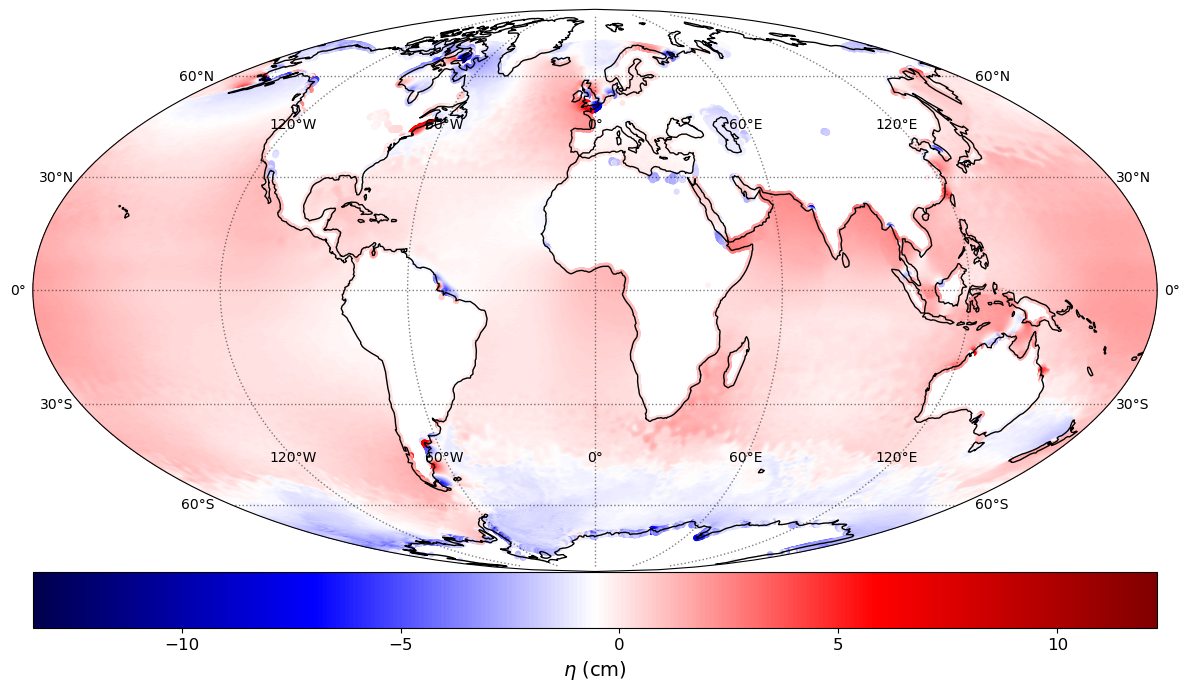

In [45]:
globe.healpix_map(coords.lat.data, coords.lon.data, ssh2, cmap='seismic', cb_lbl=r'$\eta$ (cm)', nside=512)

## Looks close enough

# Compare me

In [48]:
np.nanmax(np.abs(ssh-ssh2))

np.float64(0.0005006866455072867)

# Test on a new, "proper" one

In [2]:
new_file = os.path.join(os.getenv('OS_OGCM'), 'LLC/data/ThetaUVWSaltEta', 'tmp.nc')
ds_new = xarray.open_dataset(new_file)
ds_new

<xarray.Dataset> Size: 11GB
Dimensions:  (i: 17280, i_g: 17280, j: 12960, j_g: 12960)
Coordinates:
  * i        (i) int64 138kB 0 1 2 3 4 5 ... 17274 17275 17276 17277 17278 17279
  * i_g      (i_g) int64 138kB 0 1 2 3 4 5 ... 17275 17276 17277 17278 17279
  * j        (j) int64 104kB 0 1 2 3 4 5 ... 12954 12955 12956 12957 12958 12959
  * j_g      (j_g) int64 104kB 0 1 2 3 4 5 ... 12955 12956 12957 12958 12959
Data variables:
    Eta      (j, i) float64 2GB ...
    Salt     (j, i) float64 2GB ...
    Theta    (j, i) float64 2GB ...
    W        (j, i) float64 2GB ...
    U        (j, i_g) float64 2GB ...
    V        (j_g, i) float64 2GB ...

In [3]:
ssh3 = ds_new.Eta.data[:]

(<GeoAxes: >, <matplotlib.collections.PathCollection at 0x7a82a8811700>)

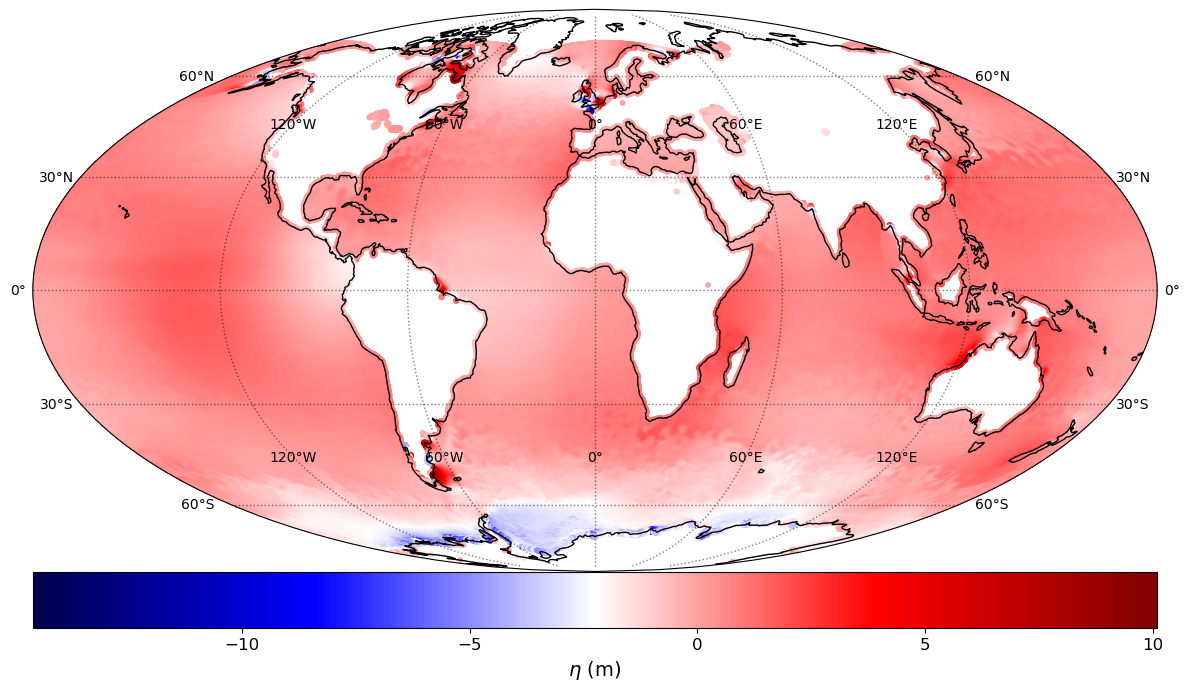

In [7]:
globe.healpix_map(coords.lat.data, coords.lon.data, ssh3, cmap='seismic', cb_lbl=r'$\eta$ (m)', nside=512)